In [15]:
!pip install seaborn plotly

In [16]:
!pip install seaborn

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Loading the dataset
df = pd.read_csv("fuel_prices_1970_2026.csv")

# Convert Date column to datetime objects (Crucial for time-series)
df['Date'] = pd.to_datetime(df['Date'])

# Show data info to verify columns
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             675 non-null    datetime64[us]
 1   Crude_Oil_Price  675 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 10.7 KB


,Date,Crude_Oil_Price
0,1970-01-01,1.21
1,1970-02-01,1.21
2,1970-03-01,1.21
3,1970-04-01,1.21
4,1970-05-01,1.21


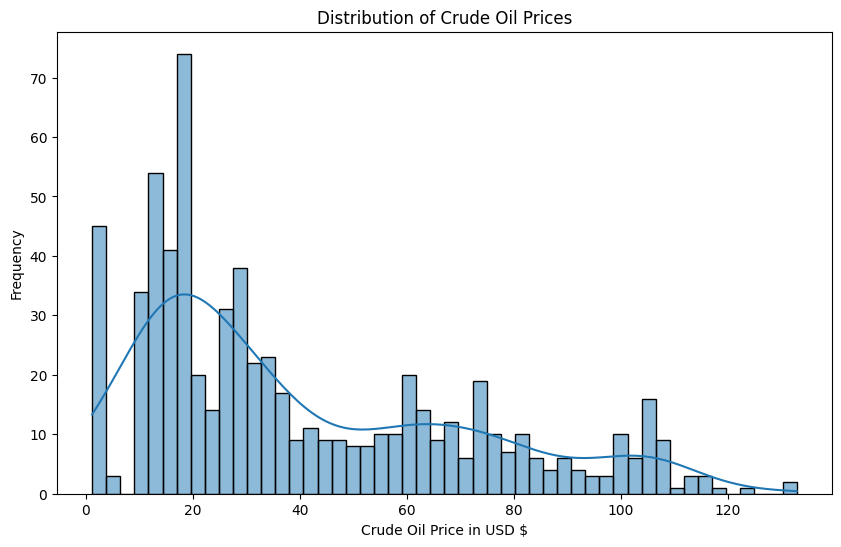

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Crude_Oil_Price'], bins=50, kde=True)
plt.title("Distribution of Crude Oil Prices")
plt.xlabel("Crude Oil Price in USD $")
plt.ylabel("Frequency")
plt.show()

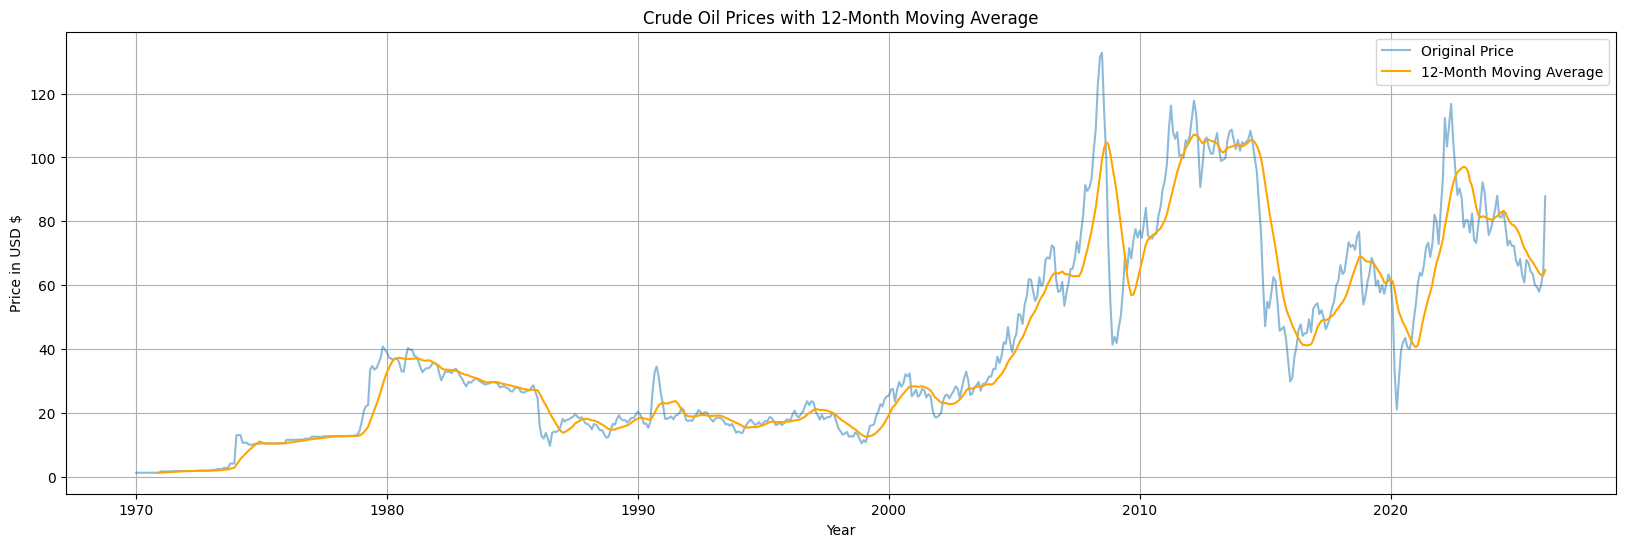

In [19]:
# Calculating 12-month moving average
df['MA_12'] = df['Crude_Oil_Price'].rolling(window=12).mean()

plt.figure(figsize=(20, 6))
plt.plot(df['Date'], df['Crude_Oil_Price'], label='Original Price', alpha=0.5)
plt.plot(df['Date'], df['MA_12'], label='12-Month Moving Average', color='orange')

plt.title("Crude Oil Prices with 12-Month Moving Average")
plt.xlabel("Year")
plt.ylabel("Price in USD $")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
df=pd.read_csv(r"fuel_prices_1970_2026.csv")
df['Date']=pd.to_datetime(df['Date'])
df.head()

,Date,Crude_Oil_Price
0,1970-01-01,1.21
1,1970-02-01,1.21
2,1970-03-01,1.21
3,1970-04-01,1.21
4,1970-05-01,1.21


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             675 non-null    datetime64[us]
 1   Crude_Oil_Price  675 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 10.7 KB


In [22]:
df.describe()

,Date,Crude_Oil_Price
count,675,675.000000
mean,1998-01-30 14:47:28,39.804040
min,1970-01-01 00:00:00,1.210000
25%,1984-01-16 12:00:00,16.533333
50%,1998-02-01 00:00:00,29.113333
75%,2012-02-15 12:00:00,61.246667
max,2026-03-01 00:00:00,132.825184
std,NaN,30.611456


In [23]:
df.tail()

,Date,Crude_Oil_Price
670,2025-11-01,59.46
671,2025-12-01,57.95
672,2026-01-01,60.04
673,2026-02-01,64.47
674,2026-03-01,87.84


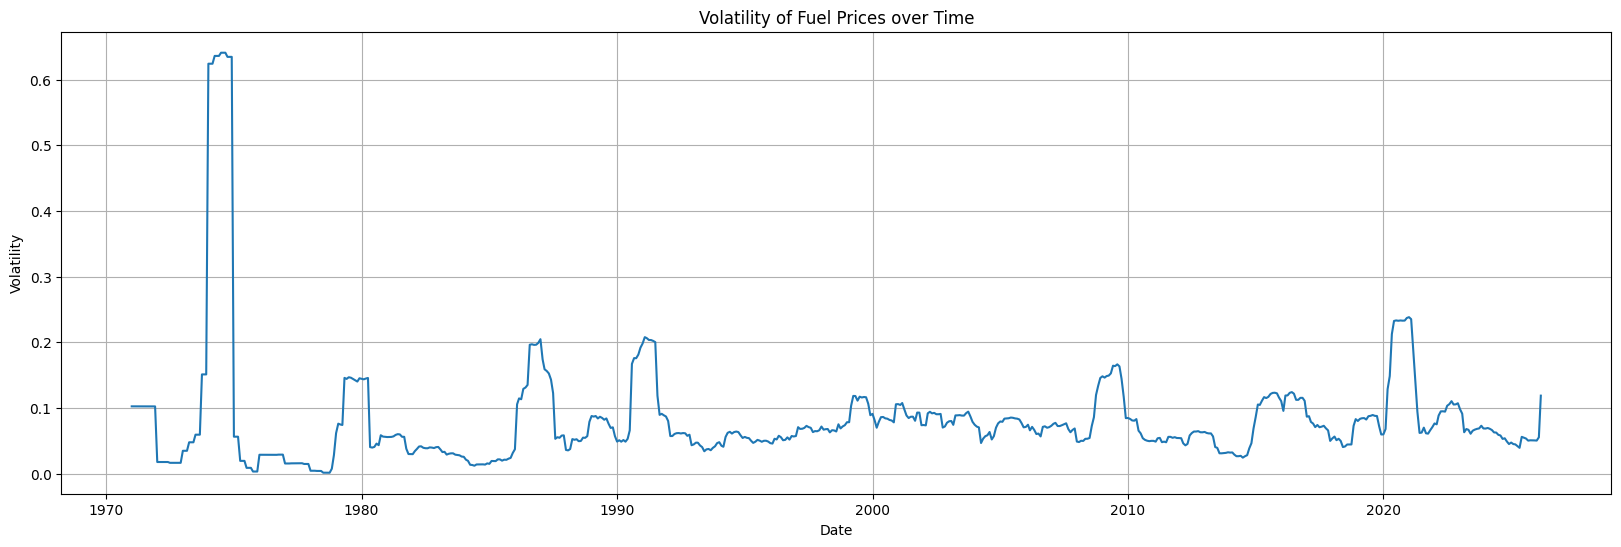

In [24]:
#volatility of fuel prices

df['Date']=pd.to_datetime(df['Date'])
df['volatility']=df['Crude_Oil_Price'].pct_change().rolling(window=12).std()
plt.figure(figsize=(20,6))
sns.lineplot(x='Date',y='volatility',data=df)
plt.title('Volatility of Fuel Prices over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

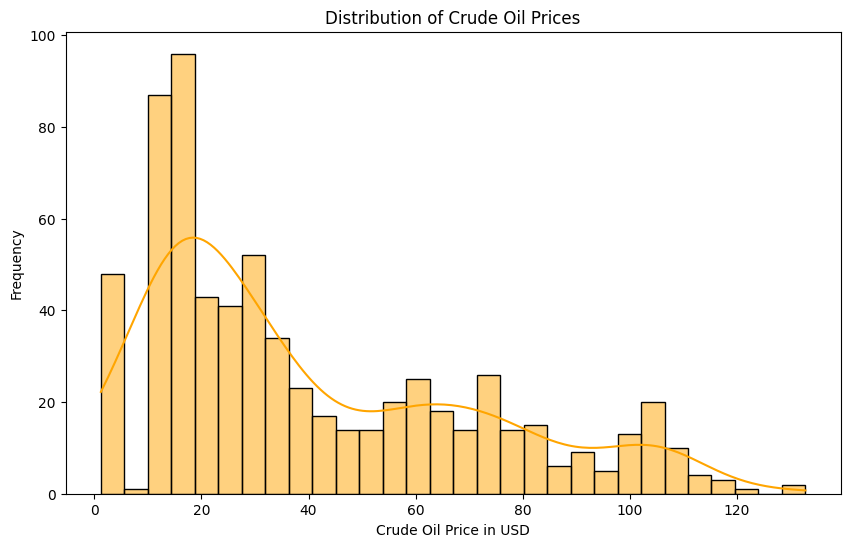

In [25]:
#DIstribution of crude oil prices(histogram)

plt.figure(figsize=(10,6))
sns.histplot(df['Crude_Oil_Price'], bins=30, kde=True, color='orange')
plt.title('Distribution of Crude Oil Prices')
plt.xlabel('Crude Oil Price in USD')
plt.ylabel('Frequency')
plt.show()

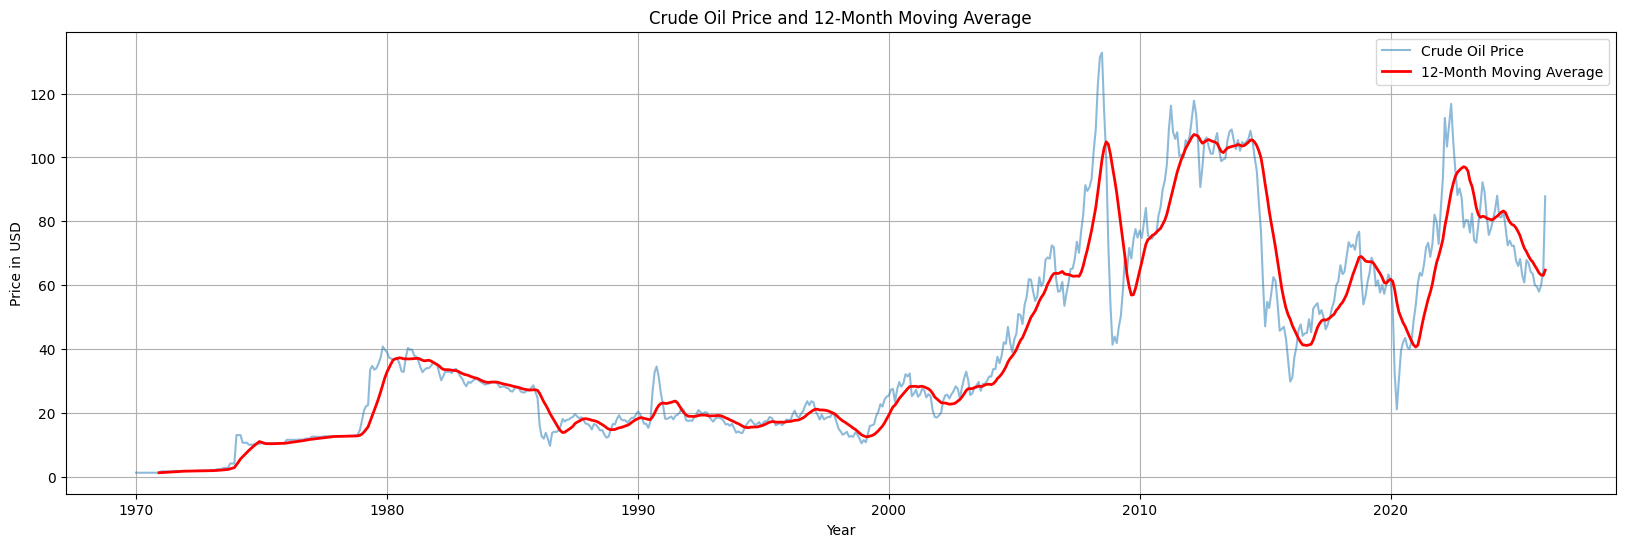

In [26]:
#calculating 12-month moving average

df['MA_12']=df['Crude_Oil_Price'].rolling(window=12).mean()

plt.figure(figsize=(20,6))
plt.plot(df['Date'], df['Crude_Oil_Price'], label='Crude Oil Price', alpha=0.5)
plt.plot(df['Date'], df['MA_12'], label='12-Month Moving Average', color='red',linewidth=2)
plt.title('Crude Oil Price and 12-Month Moving Average')
plt.xlabel("Year")
plt.ylabel("Price in USD")
plt.legend()
plt.grid(True)
plt.show()

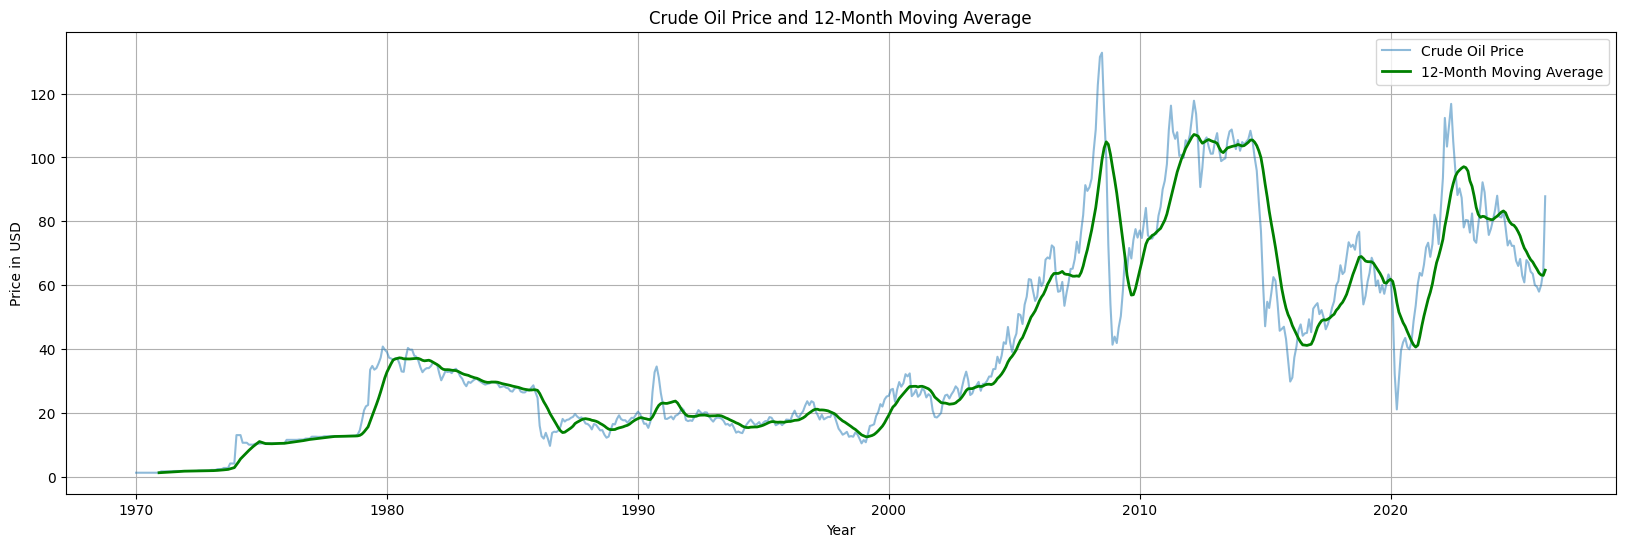

In [27]:
#Price trends with movig average

plt.figure(figsize=(20,6))
plt.plot(df['Date'], df['Crude_Oil_Price'], label='Crude Oil Price', alpha=0.5)
plt.plot(df['Date'], df['MA_12'], label='12-Month Moving Average', color='green',linewidth=2)
plt.title('Crude Oil Price and 12-Month Moving Average')
plt.xlabel("Year")
plt.ylabel("Price in USD")
plt.legend()
plt.grid(True)
plt.show()

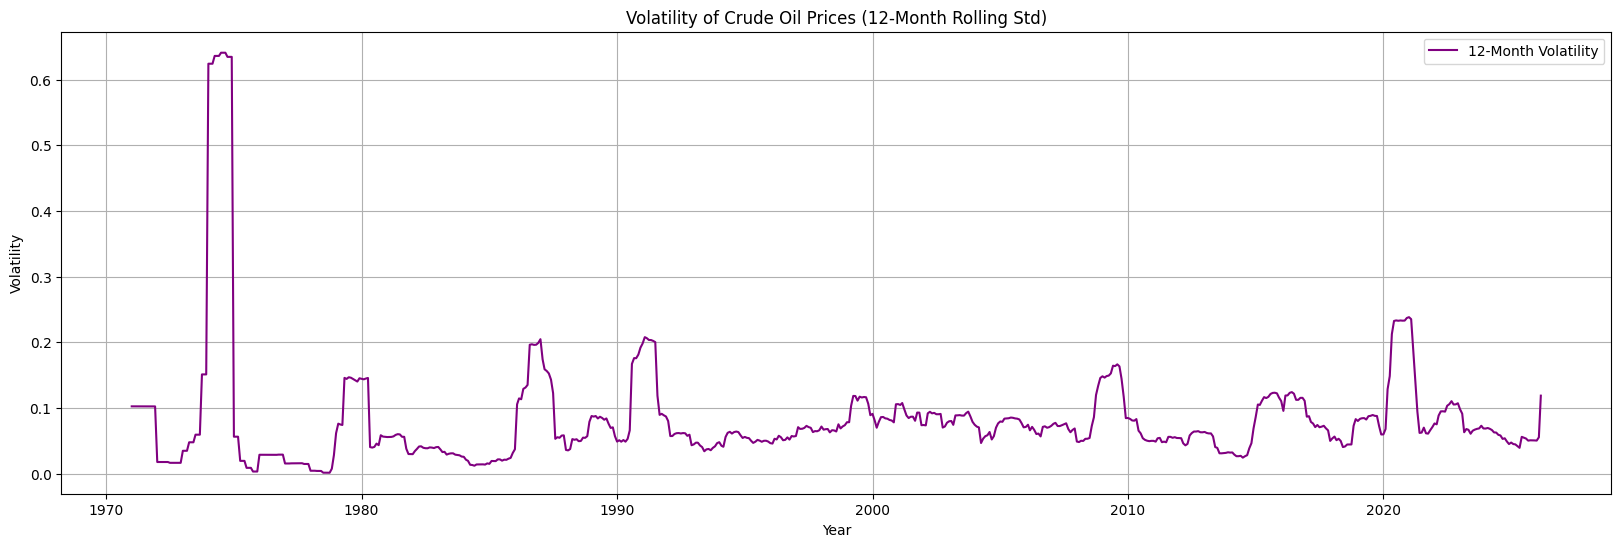

In [28]:
#Volatility Analysis(Rolling Standard Deviation)

df['volatility']=df['Crude_Oil_Price'].pct_change().rolling(window=12).std()
plt.figure(figsize=(20,6))
plt.plot(df['Date'], df['volatility'], label='12-Month Volatility', color='purple')
plt.title("Volatility of Crude Oil Prices (12-Month Rolling Std)")
plt.xlabel("Year")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

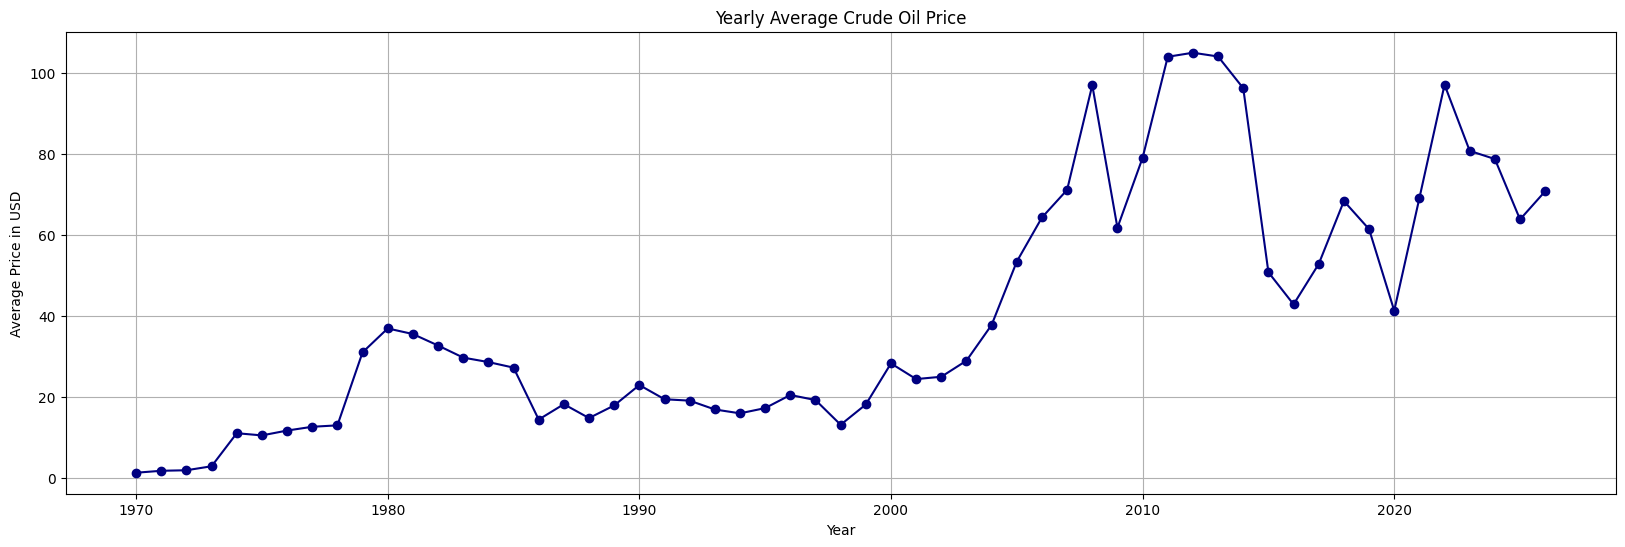

In [29]:
#Yearly Average (Bar/Line Chart)

df['Year']=df['Date'].dt.year
yearly_avg=df.groupby('Year')['Crude_Oil_Price'].mean().reset_index()
plt.figure(figsize=(20,6))
plt.plot(yearly_avg['Year'], yearly_avg['Crude_Oil_Price'], marker='o', linestyle='-', color='navy')
plt.title("Yearly Average Crude Oil Price")
plt.xlabel("Year")
plt.ylabel("Average Price in USD")
plt.grid(True)
plt.show()

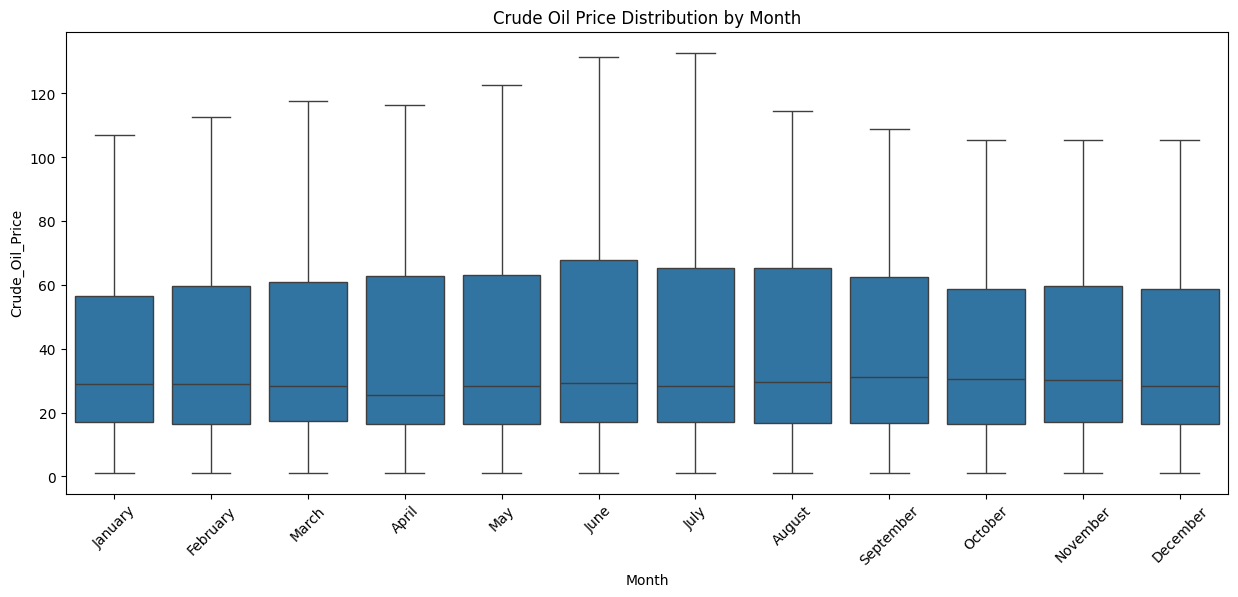

In [31]:
# Extract month for seasonality check
df['Month'] = df['Date'].dt.month_name()

plt.figure(figsize=(15, 6))
sns.boxplot(x='Month', y='Crude_Oil_Price', data=df, order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

plt.title("Crude Oil Price Distribution by Month")
plt.xticks(rotation=45)
plt.show()